# This put together some poential analysis of BC.

Kexin Dong

Feb 19, 2026

Last update: Feb 27, 2026

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA

In [19]:
LIB = pd.read_csv('MBESv2_focused_with_PAM.csv', index_col=0)
LIB_OG = pd.read_csv('MBESv2_CORRECTED.csv')

In [20]:
LFC_ABE = pd.read_csv('LFC-FDR/focused/ABE_LFC_FDR_df_focused.csv')
LFC_CBE = pd.read_csv('LFC-FDR/focused/CBE_LFC_FDR_df_focused.csv')

LFC_ABE_OG = pd.read_csv('LFC-FDR/og/ABE_LFC_FDR_df_og.csv')
LFC_CBE_OG = pd.read_csv('LFC-FDR/og/CBE_LFC_FDR_df_og.csv')

LFC_ABE_VS_BC = pd.read_csv('LFC-FDR/focused/ABE_LFC_FDR_df_vs_bc.csv')
LFC_CBE_VS_BC = pd.read_csv('LFC-FDR/focused/CBE_LFC_FDR_df_vs_bc.csv')

LFC_ABE_BC = pd.read_csv('LFC-FDR/focused/ABE_LFC_FDR_df_bc_screen.csv')
LFC_CBE_BC = pd.read_csv('LFC-FDR/focused/CBE_LFC_FDR_df_bc_screen.csv')

In [21]:
conditions = ['d5', 'd15', 'spleen', 'bm', 'men']
conditions_og = ['d5','d15','spleen','bonemarrow','meninges']

name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))
name_dict_og = dict(zip(conditions_og, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))

In [40]:
yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

## Analysis 1: NT performance in the **ORIGINAL** *ABE* and *CBE* screen

show the distribution of NTs, pointing out the noise problem.

In [ ]:
ABE_OG = LIB_OG[LIB_OG['Editor'] == 'ABE']
CBE_OG = LIB_OG[LIB_OG['Editor'] == 'CBE']

guides_ABE_OG_targ = ABE_OG[ABE_OG['classification'] == 'targeting guide']['gRNA_id']
guides_CBE_OG_targ = CBE_OG[CBE_OG['classification'] == 'targeting guide']['gRNA_id']

control_names = ['safe-targeting control',
       'non-targeting control']
guides_ABE_OG_nontarg = ABE_OG[ABE_OG['classification'].isin(control_names)]['gRNA_id']
guides_CBE_OG_nontarg = CBE_OG[CBE_OG['classification'].isin(control_names)]['gRNA_id']

ABE_OG_targ = LFC_ABE_OG[LFC_ABE_OG['gRNA_id'].isin(guides_ABE_OG_targ)]
CBE_OG_targ = LFC_CBE_OG[LFC_CBE_OG['gRNA_id'].isin(guides_CBE_OG_targ)]
ABE_OG_nontarg = LFC_ABE_OG[LFC_ABE_OG['gRNA_id'].isin(guides_ABE_OG_nontarg)]
CBE_OG_nontarg = LFC_CBE_OG[LFC_CBE_OG['gRNA_id'].isin(guides_CBE_OG_nontarg)]

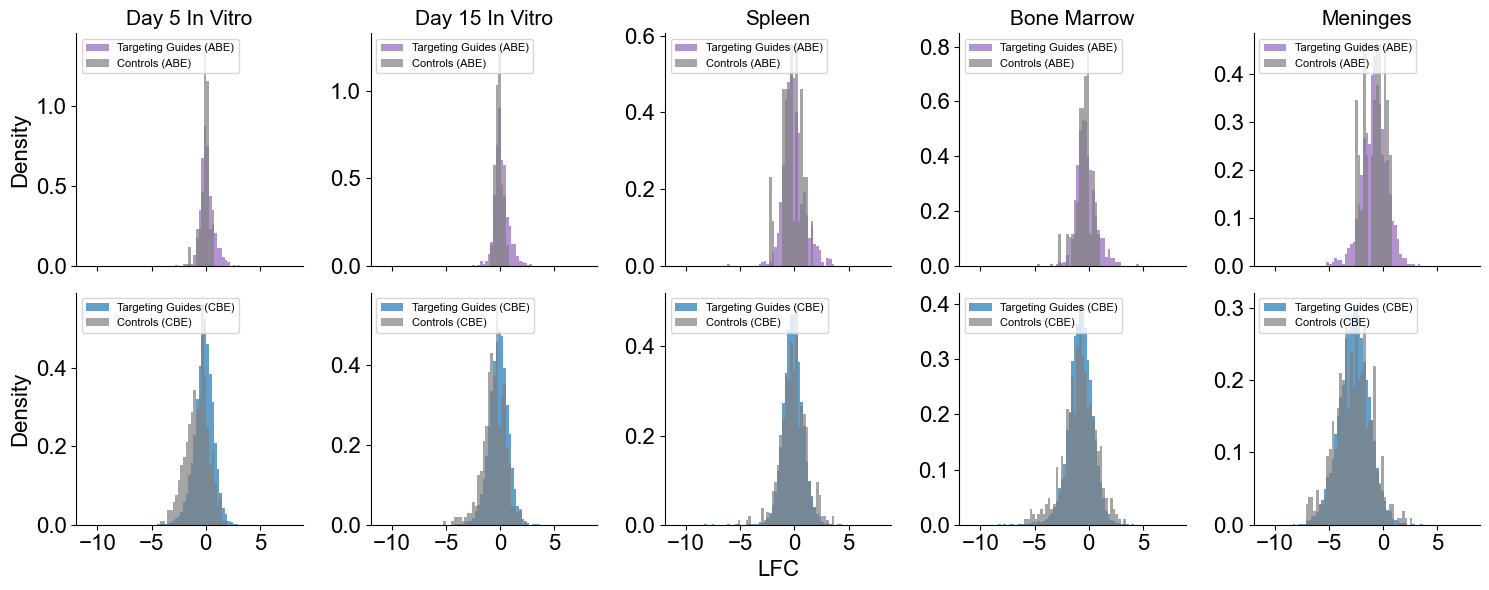

In [39]:
#visualizing the null distributions

fig, ax = plt.subplots(2,5, figsize=(15,6), sharex=True, sharey=False)

for idx, condition in enumerate(conditions_og):
    bins = np.linspace(-11,8,80)

    # plot the targeting
    ax[0][idx].hist(ABE_OG_targ[f'LFC_median_{condition}'], density=True, bins=bins, alpha=.7, color='tab:purple', label='Targeting Guides (ABE)')
    ax[1][idx].hist(CBE_OG_targ[f'LFC_median_{condition}'], density=True, bins=bins, alpha=.7, color='tab:blue', label='Targeting Guides (CBE)')

    # plot the non-targeting
    ax[0][idx].hist(ABE_OG_nontarg[f'LFC_median_{condition}'], density=True, bins=bins, alpha=.7, color='tab:gray', label='Controls (ABE)')
    ax[1][idx].hist(CBE_OG_nontarg[f'LFC_median_{condition}'], density=True, bins=bins, alpha=.7, color='tab:gray', label='Controls (CBE)')


    ax[0][idx].set_title(name_dict_og[condition], fontsize=15)

    ax[0][idx].spines[['top', 'right']].set_visible(False)
    ax[1][idx].spines[['top', 'right']].set_visible(False)

    ax[0][idx].tick_params(axis='both', which='major', labelsize=16);
    ax[1][idx].tick_params(axis='both', which='major', labelsize=16);

    ax[0][0].set_ylabel('Density', fontsize=16)
    ax[1][0].set_ylabel('Density', fontsize=16)
    ax[1][2].set_xlabel('LFC', fontsize=16)

    ax[0][0].set_xticks([-10,-5,0,  5])
    ax[0][idx].legend(fontsize=8, loc='upper left')
    ax[1][idx].legend(fontsize=8, loc='upper left')

fig.tight_layout()
plt.savefig('figures/bc_1.pdf')

## Analysis 2: Correlate BC screen LFC to EPO screen LFC of NON-TARGETING GUIDES (that is included in both).

In [42]:
LIB['classification'].unique()

array(['targeting guide', 'non-targeting control',
       'essential truncation guide', 'safe-targeting control'],
      dtype=object)

In [68]:
#calculating z-scores for standardization of comparison
samples = ['bm', 'd15', 'd5', 'men', 'spleen']
def z_score(df, samples):
    for x in samples:
        col_median = f'LFC_median_{x}'
        avg = np.average(df[col_median])
        std = np.std(df[col_median])
        z_scores = (df[col_median]-avg)/std
        df[f'z_score_{x}'] = z_scores
    return df

ABE_BC_LFC_table_w_editing_z_score = LFC_ABE_BC.copy()
ABE_EPO_LFC_table_w_editing_z_score = LFC_ABE.copy()
CBE_BC_LFC_table_w_editing_z_score = LFC_CBE_BC.copy()
CBE_EPO_LFC_table_w_editing_z_score = LFC_CBE.copy()

ABE_BC_LFC_table_w_editing_z_score = z_score(ABE_BC_LFC_table_w_editing_z_score, samples)
ABE_EPO_LFC_table_w_editing_z_score = z_score(ABE_EPO_LFC_table_w_editing_z_score, samples)
CBE_BC_LFC_table_w_editing_z_score = z_score(CBE_BC_LFC_table_w_editing_z_score, samples)
CBE_EPO_LFC_table_w_editing_z_score = z_score(CBE_EPO_LFC_table_w_editing_z_score, samples)

In [69]:
targeting_names = ['targeting guide', 'essential truncation guide']
guides_focused_targ = LIB[LIB['classification'].isin(targeting_names)]['gRNA_id']
control_names = ['safe-targeting control',
       'non-targeting control']
guides_nontarg = LIB[LIB['classification'].isin(control_names)]['gRNA_id']

ABE_targ = ABE_EPO_LFC_table_w_editing_z_score[ABE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
CBE_targ = CBE_EPO_LFC_table_w_editing_z_score[CBE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
ABE_nontarg = ABE_EPO_LFC_table_w_editing_z_score[ABE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)
CBE_nontarg = CBE_EPO_LFC_table_w_editing_z_score[CBE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)

ABE_targ_bc = ABE_BC_LFC_table_w_editing_z_score[ABE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
CBE_targ_bc = CBE_BC_LFC_table_w_editing_z_score[CBE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
ABE_nontarg_bc = ABE_BC_LFC_table_w_editing_z_score[ABE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)
CBE_nontarg_bc = CBE_BC_LFC_table_w_editing_z_score[CBE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)

5
206
5
206
5
206
5
206
360
5
360
5
360
5
360
5


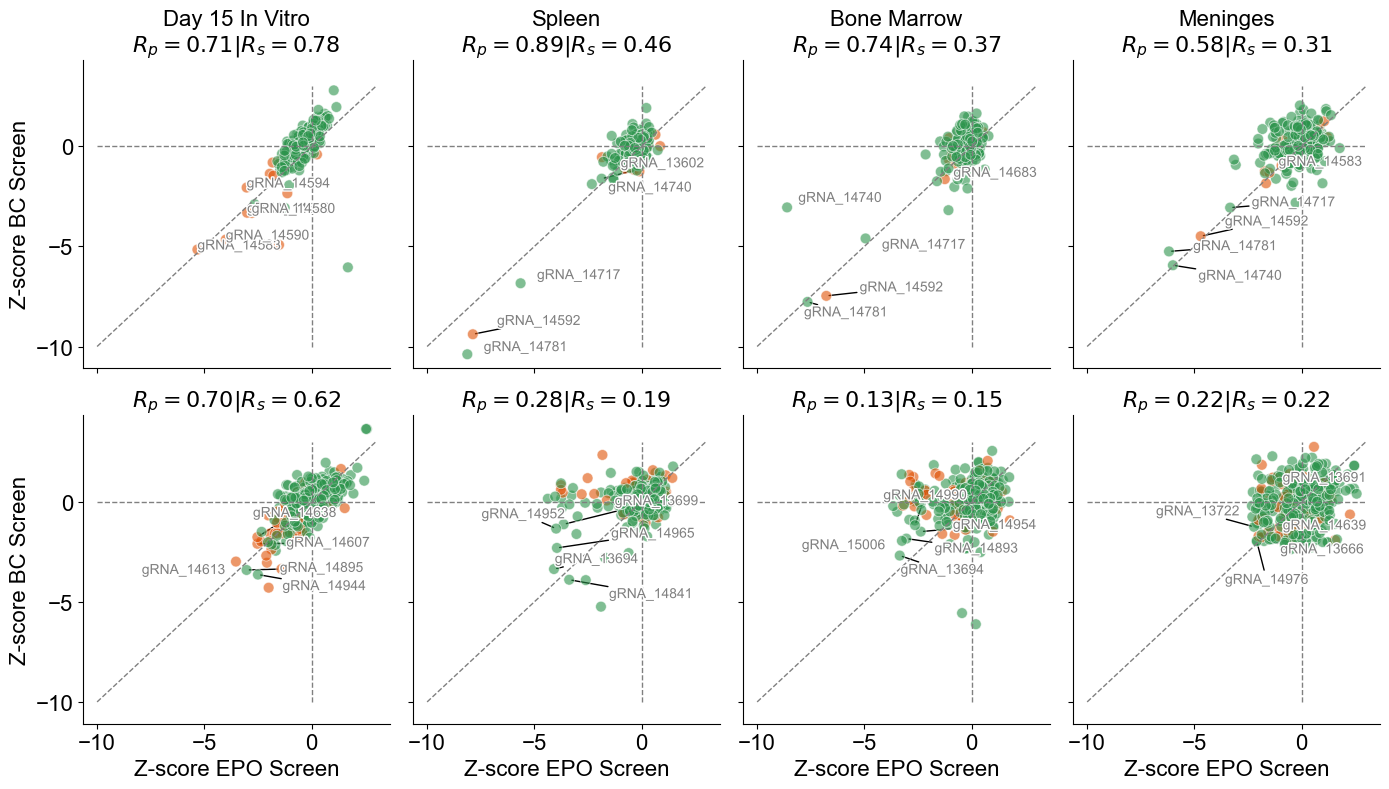

In [73]:
fig, ax = plt.subplots(2, 4, figsize = (14, 8), sharex=True, sharey = True)

conditions = ['d5', 'd15', 'spleen', 'bm', 'men']
conditions_og = ['d5','d15','spleen','bonemarrow','meninges']

name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))
name_dict_og = dict(zip(conditions_og, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))


# ABE first
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = ABE_nontarg[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = ABE_nontarg_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc, on='gRNA_id')

    # correlation calculation 
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        if i >0:
            adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    print(len(df))
    color_dict_classification = {'non-targeting control':greens[4], 'safe-targeting control':yellows[4]}
    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[0][i], hue='classification', palette=color_dict_classification, s=60, alpha=.6, legend=False)
    ax[0][i].spines[['top', 'right']].set_visible(False)
    ax[0][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[0][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].set_title(f'{name_dict[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[0][i].set_ylabel(f'Z-score BC Screen', fontsize=16)
    
# then CBE
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = CBE_nontarg[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = CBE_nontarg_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc)
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    print(len(df))

    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[1][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        adjust_text(texts,only_move={'texts':'xy'}, ax=ax[1][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[1][i], hue='classification', palette=color_dict_classification, s=60, alpha=.6, legend=False)
    ax[1][i].spines[['top', 'right']].set_visible(False)
    ax[1][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[1][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].set_title(f'$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[1][i].set_xlabel('Z-score EPO Screen', fontsize=16)
    ax[1][i].set_ylabel('Z-score BC Screen', fontsize=16)

fig.tight_layout()
plt.savefig('figures/bc_2.pdf')

## Analysis 3: removing some NT guides and calculate FDR again.

show the changes in FDR distribution in general.

In [79]:
# get a list of all guides within top 5% of both in any of the tissue.

import math

abe_removed = cbe_removed = []

for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = ABE_nontarg[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = ABE_nontarg_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc, on='gRNA_id')

    print(f'5% of ABE = {math.floor(len(df)*0.05)}')
    
    q_epo = df['epo_z_score'].quantile(0.05)
    q_bc  = df['bc_z_score'].quantile(0.05)

    tb = df[
        (df['epo_z_score'] <= q_epo) &
        (df['bc_z_score'] <= q_bc)
    ]
    abe_removed.extend(tb['gRNA_id'].tolist())

    epo = CBE_nontarg[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = CBE_nontarg_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc, on='gRNA_id')
    print(f'5% of CBE = {math.floor(len(df)*0.05)}')

    q_epo = df['epo_z_score'].quantile(0.05)
    q_bc  = df['bc_z_score'].quantile(0.05)
    tb = df[
        (df['epo_z_score'] <= q_epo) &
        (df['bc_z_score'] <= q_bc)
    ]
    cbe_removed.extend(tb['gRNA_id'].tolist())


5% of ABE = 10
5% of CBE = 18
5% of ABE = 10
5% of CBE = 18
5% of ABE = 10
5% of CBE = 18
5% of ABE = 10
5% of CBE = 18


In [80]:
abe_removed

['gRNA_14580',
 'gRNA_14582',
 'gRNA_14583',
 'gRNA_14590',
 'gRNA_14594',
 'gRNA_14771',
 'gRNA_14601',
 'gRNA_14607',
 'gRNA_14613',
 'gRNA_14616',
 'gRNA_14618',
 'gRNA_14644',
 'gRNA_14648',
 'gRNA_14650',
 'gRNA_14895',
 'gRNA_14944',
 'gRNA_14976',
 'gRNA_15002',
 'gRNA_13602',
 'gRNA_14592',
 'gRNA_14717',
 'gRNA_14740',
 'gRNA_14781',
 'gRNA_13657',
 'gRNA_13694',
 'gRNA_13699',
 'gRNA_14841',
 'gRNA_14952',
 'gRNA_14965',
 'gRNA_14589',
 'gRNA_14592',
 'gRNA_14683',
 'gRNA_14717',
 'gRNA_14740',
 'gRNA_14781',
 'gRNA_13694',
 'gRNA_14893',
 'gRNA_15006',
 'gRNA_14592',
 'gRNA_14717',
 'gRNA_14740',
 'gRNA_14781',
 'gRNA_13666',
 'gRNA_14976']

5
206
5
206
5
206
5
206
360
5
360
5
360
5
360
5


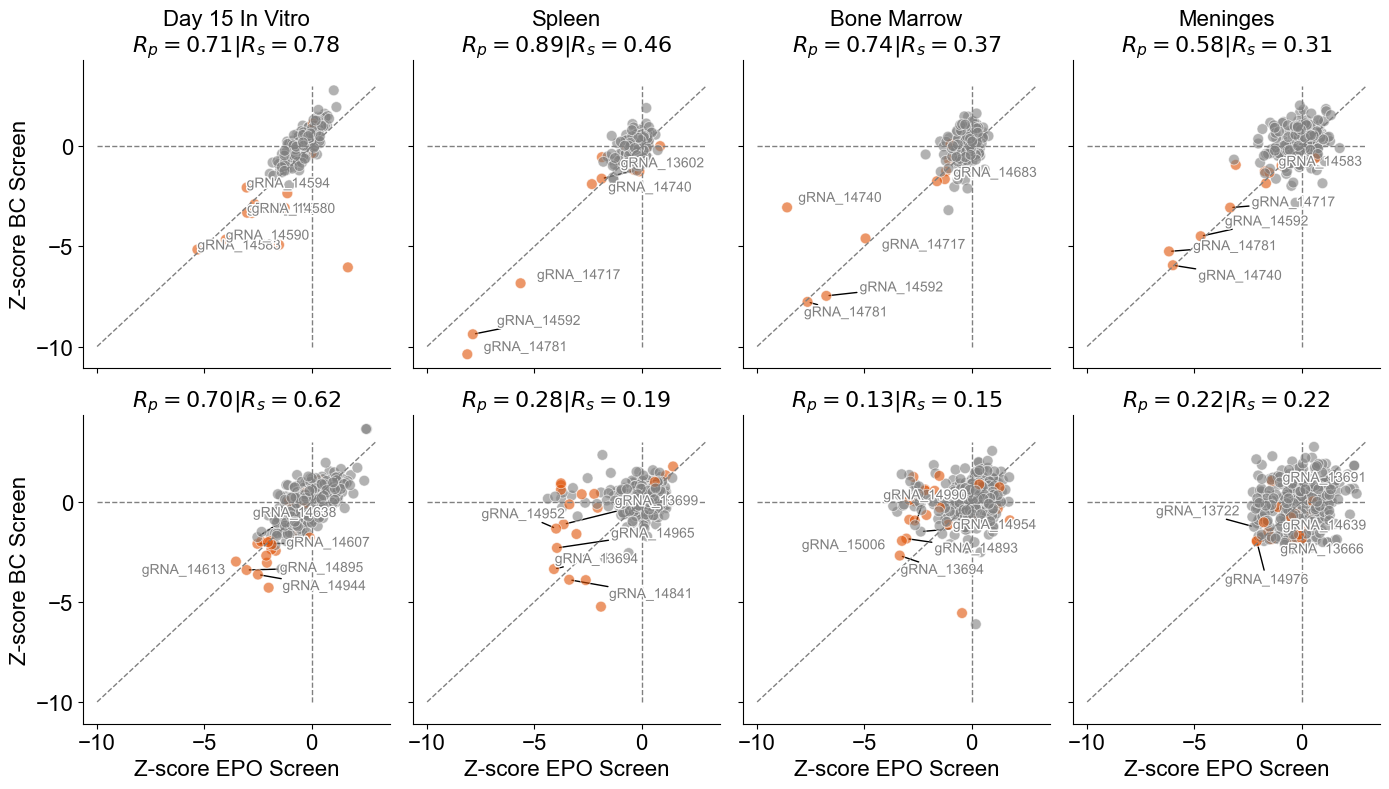

In [82]:
fig, ax = plt.subplots(2, 4, figsize = (14, 8), sharex=True, sharey = True)

conditions = ['d5', 'd15', 'spleen', 'bm', 'men']
conditions_og = ['d5','d15','spleen','bonemarrow','meninges']

name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))
name_dict_og = dict(zip(conditions_og, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))


# ABE first
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = ABE_nontarg[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = ABE_nontarg_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc, on='gRNA_id')

    abe_removed_mask = df['gRNA_id'].isin(abe_removed)
    df['removed'] = np.where(abe_removed_mask, 'removed', 'kept')
    # correlation calculation 
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        if i >0:
            adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    print(len(df))
    color_dict_removed = {'removed':yellows[4], 'kept':'grey'}
    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[0][i], hue='removed', palette=color_dict_removed, s=60, alpha=.6, legend=False)
    ax[0][i].spines[['top', 'right']].set_visible(False)
    ax[0][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[0][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].set_title(f'{name_dict[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[0][i].set_ylabel(f'Z-score BC Screen', fontsize=16)
    
# then CBE
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = CBE_nontarg[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = CBE_nontarg_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc, on='gRNA_id')
    cbe_removed_mask = df['gRNA_id'].isin(cbe_removed)
    df['removed'] = np.where(cbe_removed_mask, 'removed', 'kept')
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    print(len(df))

    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[1][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        adjust_text(texts,only_move={'texts':'xy'}, ax=ax[1][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[1][i], hue='removed', palette=color_dict_removed, s=60, alpha=.6, legend=False)
    ax[1][i].spines[['top', 'right']].set_visible(False)
    ax[1][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[1][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].set_title(f'$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[1][i].set_xlabel('Z-score EPO Screen', fontsize=16)
    ax[1][i].set_ylabel('Z-score BC Screen', fontsize=16)

fig.tight_layout()
plt.savefig('figures/bc_3_1.pdf')

### 3.2 removing these NTs and calculating ABE EPO and CBE EPO FDR values again

In [ ]:
#set np random seed for reproducibility
np.random.seed(0)
null=['non-targeting control', 'safe-targeting control']

In [93]:
ABE_controls = ABE_EPO_LFC_table_w_editing_z_score[ABE_EPO_LFC_table_w_editing_z_score['classification'].isin(control_names)].reset_index(drop=True)
ABE_controls = ABE_controls[~ABE_controls['gRNA_id'].isin(abe_removed)].reset_index(drop=True)
CBE_controls = CBE_EPO_LFC_table_w_editing_z_score[CBE_EPO_LFC_table_w_editing_z_score['classification'].isin(control_names)].reset_index(drop=True)
CBE_controls = CBE_controls[~CBE_controls['gRNA_id'].isin(cbe_removed)].reset_index(drop=True)

In [95]:
ABE_EPO_samps_to_merge = ABE_BC_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'],
['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
ABE_EPO_new_name = ABE_BC_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

CBE_BC_samps_to_merge = [['bm1', 'bm2', 'bm4'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5-rep1', 'd5-rep2', 'd5-rep3','d5-rep4', 'd5-rep5'],
['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'],
['lib'],
['men1', 'men2', 'men4'], 
['spleen1', 'spleen2', 'spleen4']]
CBE_BC_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

CBE_EPO_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5-rep1', 'd5-rep2', 'd5-rep3','d5-rep4', 'd5-rep5'],
['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'],
['lib'],
['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
CBE_EPO_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

In [96]:
ABE_EPO_SAMP_DICT = ABE_BC_SAMP_DICT = dict(zip(ABE_EPO_new_name, ABE_EPO_samps_to_merge))
CBE_BC_SAMP_DICT = dict(zip(CBE_BC_new_name, CBE_BC_samps_to_merge))
CBE_EPO_SAMP_DICT = dict(zip(CBE_EPO_new_name, CBE_EPO_samps_to_merge))

In [97]:
#generate null distributions with bootstrapping
conditions = ['d5', 'd15', 'spleen', 'bm', 'men']

ABE_bootstrapped_nulls = []
CBE_bootstrapped_nulls = []

for condition in conditions:
    samp_of_interest_CBE = CBE_EPO_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_EPO_SAMP_DICT[condition]

    #combine replicates and bootstrap sample
    nt_gRNA_values_CBE = CBE_controls[samp_of_interest_CBE].to_numpy().flatten()
    bootstrapped_dist_CBE = np.random.choice(nt_gRNA_values_CBE, size=10000, replace=True)

    nt_gRNA_values_ABE = ABE_controls[samp_of_interest_ABE].to_numpy().flatten()
    bootstrapped_dist_ABE = np.random.choice(nt_gRNA_values_ABE, size=10000, replace=True)

    CBE_bootstrapped_nulls.append(bootstrapped_dist_CBE)
    ABE_bootstrapped_nulls.append(bootstrapped_dist_ABE)

#create dictionaries for both
ABE_null_dict = dict(zip(conditions, ABE_bootstrapped_nulls))
CBE_null_dict = dict(zip(conditions, CBE_bootstrapped_nulls))

In [98]:
len(nt_gRNA_values_CBE)

1695

In [99]:
len(nt_gRNA_values_ABE)

965

### 3.3 FDR recalculation

In [101]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests

# Function to compute empirical p-values
def empirical_p_value(observed, null_distribution):
    S_high = sum(null_distribution >= observed)
    S_low = sum(null_distribution <= observed)
    N = len(null_distribution)

    # Compute two-sided p-value
    p_high = (S_high + 1) / (N + 1)
    p_low = (S_low + 1) / (N + 1)
    return p_high, p_low

def two_sided_FDR(condition_of_interest, samp_of_interest, LFC_df, null_dict):
    ''' 
    condition_of_interest = name of condition (e.g. "spleen")
    samp_of_interest = list of all replicates ["spleen1", "spleen2", "spleen3"]
    LFC_df = dataframe with LFC values
    null_dict = dictionary containing bootstrapped null distributions for each tissue & editor combination
    '''

    # Load the null distribution
    nt_gRNA_values = null_dict[condition_of_interest]

    # Targeting gRNAs (including NT for completeness)
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])
    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    combined_p_values_high_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_high
    ])
    combined_p_values_low_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    adjusted_p_values_high_stouffers = multipletests(combined_p_values_high_stouffers, method='fdr_bh')[1]
    adjusted_p_values_low_stouffers = multipletests(combined_p_values_low_stouffers, method='fdr_bh')[1]

    # Store results in the dataframe
    LFC_df[f'p_high_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_high
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_low
    LFC_df[f'FDR_high_{condition_of_interest}_fishers'] = adjusted_p_values_high
    LFC_df[f'FDR_low_{condition_of_interest}_fishers'] = adjusted_p_values_low

    LFC_df[f'p_high_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_high_stouffers
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_low_stouffers
    LFC_df[f'FDR_high_{condition_of_interest}_stouffers'] = adjusted_p_values_high_stouffers
    LFC_df[f'FDR_low_{condition_of_interest}_stouffers'] = adjusted_p_values_low_stouffers

    #Combine low and high FDRs for ease of manipulation and plotting
    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_fishers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_fishers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_fishers'] = min_FDR

    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_stouffers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_stouffers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_stouffers'] = min_FDR

    return LFC_df

In [104]:
#loading in barcode counts
ABE_EPO_COUNTS = pd.read_csv('/Users/kexindong/Documents/GitHub/PhD-FSR-MH-Lab/07_B-ALL_resubmission_20250819/validation_screen_analysis/ABE_EPO_COUNTS.txt', sep='\t')
CBE_EPO_COUNTS = pd.read_csv('/Users/kexindong/Documents/GitHub/PhD-FSR-MH-Lab/07_B-ALL_resubmission_20250819/validation_screen_analysis/CBE_EPO_COUNTS.txt', sep='\t')

In [105]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_EPO_COUNTS.columns[2:])
ABE_EPO_RPM = ABE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_EPO_RPM[k] = rpm

In [106]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_EPO_COUNTS.columns[2:])
CBE_EPO_RPM = CBE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_EPO_RPM[k] = rpm

In [107]:
#start with ABE

def LFC_table_generator(RPM_df, samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3']):
    """ 
    Function for generating LFC values
    RPM_df = dataframe containing RPM values (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    t0_comparison = list containing base mean values for LFC calculation
    """

    dmso_median = np.median(RPM_df[t0_comparison], axis=1)

    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):

        samp_of_interest = samp_dict[condition_of_interest]

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM_df[k]
            lfc = np.log2(col/dmso_median)
            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['Input_median'] = dmso_median
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

In [108]:
ABE_EPO_samps_to_merge = ABE_BC_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'],
['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
ABE_EPO_new_name = ABE_BC_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

CBE_BC_samps_to_merge = [['bm1', 'bm2', 'bm4'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5-rep1', 'd5-rep2', 'd5-rep3','d5-rep4', 'd5-rep5'],
['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'],
['lib'],
['men1', 'men2', 'men4'], 
['spleen1', 'spleen2', 'spleen4']]
CBE_BC_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

CBE_EPO_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5-rep1', 'd5-rep2', 'd5-rep3','d5-rep4', 'd5-rep5'],
['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'],
['lib'],
['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
CBE_EPO_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

In [109]:
ABE_EPO_SAMP_DICT = ABE_BC_SAMP_DICT = dict(zip(ABE_EPO_new_name, ABE_EPO_samps_to_merge))
CBE_BC_SAMP_DICT = dict(zip(CBE_BC_new_name, CBE_BC_samps_to_merge))
CBE_EPO_SAMP_DICT = dict(zip(CBE_EPO_new_name, CBE_EPO_samps_to_merge))

In [110]:
#generate LFC tables
ABE_EPO_LFC = LFC_table_generator(ABE_EPO_RPM, ABE_EPO_SAMP_DICT, t0_comparison=['input'])
CBE_EPO_LFC = LFC_table_generator(CBE_EPO_RPM, CBE_EPO_SAMP_DICT, t0_comparison=['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'])

In [111]:
fp = '/Users/kexindong/Documents/GitHub/PhD-FSR-MH-Lab/07_B-ALL_resubmission_20250819/validation_screen_analysis/MLE'
D5_ABE_BC = pd.read_csv(os.path.join(fp,'ABE_BC','d5.csv'))
D5_ABE_EPO = pd.read_csv(os.path.join(fp,'ABE_EPO','d5.csv'))
D5_CBE_BC = pd.read_csv(os.path.join(fp,'CBE_BC','d5.csv'))
D5_CBE_EPO = pd.read_csv(os.path.join(fp,'CBE_EPO','d5.csv'))

In [112]:
#and then adding in editing information to the dataframe
ABE_EPO_EDITING = D5_ABE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_EPO_EDITING = ABE_EPO_EDITING[ABE_EPO_EDITING['gRNA_id'].isin(ABE_EPO_COUNTS['sgRNA'])]

CBE_EPO_EDITING = D5_CBE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_EPO_EDITING = CBE_EPO_EDITING[CBE_EPO_EDITING['gRNA_id'].isin(CBE_EPO_COUNTS['sgRNA'])]

In [114]:
#also add in information about the edits of interest
library = LIB[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]
library

,gRNA_id,gene_name_m_corrected,gene_name_h,HGVSp_m,HGVSp_h,classification,classification_m
0,gRNA_2,Abl1,ABL1,Non-coding,NaN,targeting guide,Intron
1,gRNA_4,Abl1,ABL1,E1060K,E1048K,targeting guide,Missense
2,gRNA_19,Abl1,ABL1,P592L,P573L,targeting guide,Missense
3,gRNA_21,Abl1,ABL1,A737T,A719T,targeting guide,Missense
4,gRNA_85,Akt1,AKT1,D323G,D323G,targeting guide,Missense
...,...,...,...,...,...,...,...
1628,gRNA_15007,NaN,NaN,NaN,NaN,non-targeting control,NaN
1629,gRNA_15008,NaN,NaN,NaN,NaN,non-targeting control,NaN
1630,gRNA_15009,NaN,NaN,NaN,NaN,non-targeting control,NaN
1631,gRNA_15010,NaN,NaN,NaN,NaN,non-targeting control,NaN


In [116]:
ABE_EPO_EDITING = pd.merge(ABE_EPO_EDITING, library, on='gRNA_id')
CBE_EPO_EDITING = pd.merge(CBE_EPO_EDITING, library, on='gRNA_id')

ABE_EPO_LFC_table_w_editing = pd.merge(ABE_EPO_LFC, ABE_EPO_EDITING, on='gRNA_id')
CBE_EPO_LFC_table_w_editing = pd.merge(CBE_EPO_LFC, CBE_EPO_EDITING, on='gRNA_id')

In [117]:
#first perform computation for ABE samples

conditions = ['d5', 'd15', 'spleen', 'bm', 'men']

df_holder_ABE = []
for condition_of_interest in conditions:

    samp_of_interest = ABE_EPO_SAMP_DICT[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, ABE_EPO_LFC_table_w_editing, ABE_null_dict)

    df_holder_ABE.append(LFC_df)

combined_LFC_FDR_ABE_removed = pd.concat(df_holder_ABE, axis=1)
combined_LFC_FDR_ABE_removed = combined_LFC_FDR_ABE_removed.loc[:,~combined_LFC_FDR_ABE_removed.columns.duplicated()].copy()

In [ ]:
combined_LFC_FDR_ABE_removed

In [118]:
#then do the same for CBE samples
conditions = ['d5', 'd15', 'spleen', 'bm', 'men']

df_holder_CBE = []
for condition_of_interest in conditions:

    samp_of_interest = CBE_EPO_SAMP_DICT[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, CBE_EPO_LFC_table_w_editing, CBE_null_dict)

    df_holder_CBE.append(LFC_df)

combined_LFC_FDR_CBE_removed = pd.concat(df_holder_CBE, axis=1)
combined_LFC_FDR_CBE_removed = combined_LFC_FDR_CBE_removed.loc[:,~combined_LFC_FDR_CBE_removed.columns.duplicated()].copy()

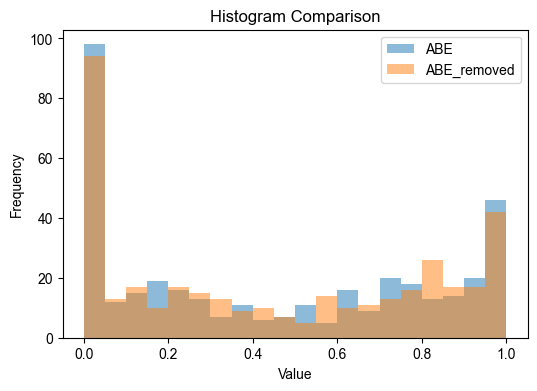

In [123]:
# plot FDR distributions for each tissue and editor combination
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(LFC_ABE['FDR_bm_fishers'], bins=20, alpha=0.5, label='ABE')
plt.hist(combined_LFC_FDR_ABE_removed['FDR_bm_fishers'], bins=20, alpha=0.5, label='ABE_removed')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram Comparison')

plt.show()

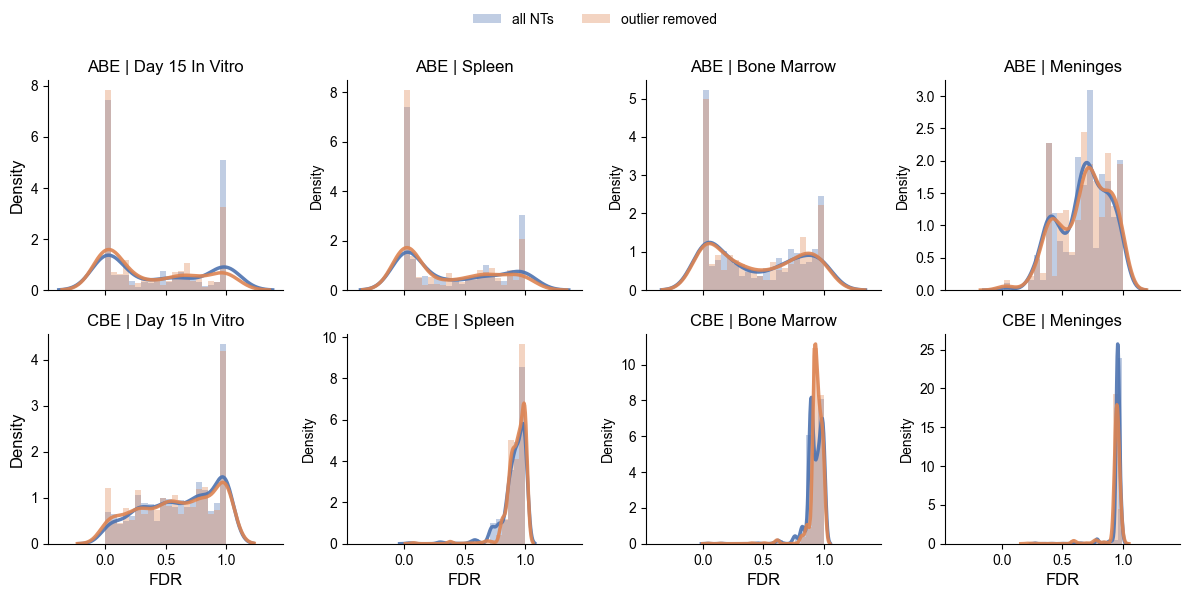

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Layout: 2 rows (ABE/CBE) x 4 cols (tissues)
fig, ax = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=False)

tissues = ['d15', 'spleen', 'bm', 'men']
titles = [name_dict[t] for t in tissues]  # uses your name_dict

# Helper: compute shared bins (important for fair comparison)
def shared_bins(x1, x2, bins=20):
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    x1 = x1[np.isfinite(x1)]
    x2 = x2[np.isfinite(x2)]
    lo = min(x1.min() if x1.size else 0, x2.min() if x2.size else 0)
    hi = max(x1.max() if x1.size else 1, x2.max() if x2.size else 1)
    if lo == hi:  # avoid zero-range bins
        lo -= 0.5
        hi += 0.5
    return np.linspace(lo, hi, bins + 1)

# Helper: plot hist + KDE on one axis
def hist_with_kde(ax_, x_all, x_removed, bins, title, show_xlabel=False):

    color_all = "#4C72B0"
    color_removed = "#DD8452"

    x_all = np.asarray(x_all)
    x_removed = np.asarray(x_removed)
    x_all = x_all[np.isfinite(x_all)]
    x_removed = x_removed[np.isfinite(x_removed)]

    # histogram
    ax_.hist(
        x_all, bins=bins, density=True,
        alpha=0.35, color=color_all, label='all NTs'
    )

    ax_.hist(
        x_removed, bins=bins, density=True,
        alpha=0.35, color=color_removed, label='outlier removed'
    )

    # KDE curves (same colors!)
    if len(x_all) >= 5:
        sns.kdeplot(
            x=x_all, ax=ax_,
            color=color_all,
            linewidth=2.5,
            alpha=0.9
        )

    if len(x_removed) >= 5:
        sns.kdeplot(
            x=x_removed, ax=ax_,
            color=color_removed,
            linewidth=2.5,
            alpha=0.9
        )

    ax_.set_title(title, fontsize=12)
    ax_.spines[['top','right']].set_visible(False)

    if show_xlabel:
        ax_.set_xlabel('FDR', fontsize=12)

# ======= ABE row (row 0) =======
for i, t in enumerate(tissues):
    col = f'FDR_{t}_fishers'  # adjust if needed

    x_all = LFC_ABE[col].dropna().values
    x_removed = combined_LFC_FDR_ABE_removed[col].dropna().values

    bins = shared_bins(x_all, x_removed, bins=20)
    hist_with_kde(
        ax_=ax[0, i],
        x_all=x_all,
        x_removed=x_removed,
        bins=bins,
        title=f'ABE | {titles[i]}',
        show_xlabel=False
    )

# ======= CBE row (row 1) =======
for i, t in enumerate(tissues):
    col = f'FDR_{t}_fishers'  # adjust if needed

    x_all = LFC_CBE[col].dropna().values
    x_removed = combined_LFC_FDR_CBE_removed[col].dropna().values

    bins = shared_bins(x_all, x_removed, bins=20)
    hist_with_kde(
        ax_=ax[1, i],
        x_all=x_all,
        x_removed=x_removed,
        bins=bins,
        title=f'CBE | {titles[i]}',
        show_xlabel=True
    )

# Shared y label on left side
ax[0, 0].set_ylabel('Density', fontsize=12)
ax[1, 0].set_ylabel('Density', fontsize=12)

# One legend for the whole figure (avoid repeated legends per subplot)
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('figures/bc_3_2.pdf', bbox_inches='tight')
plt.show()

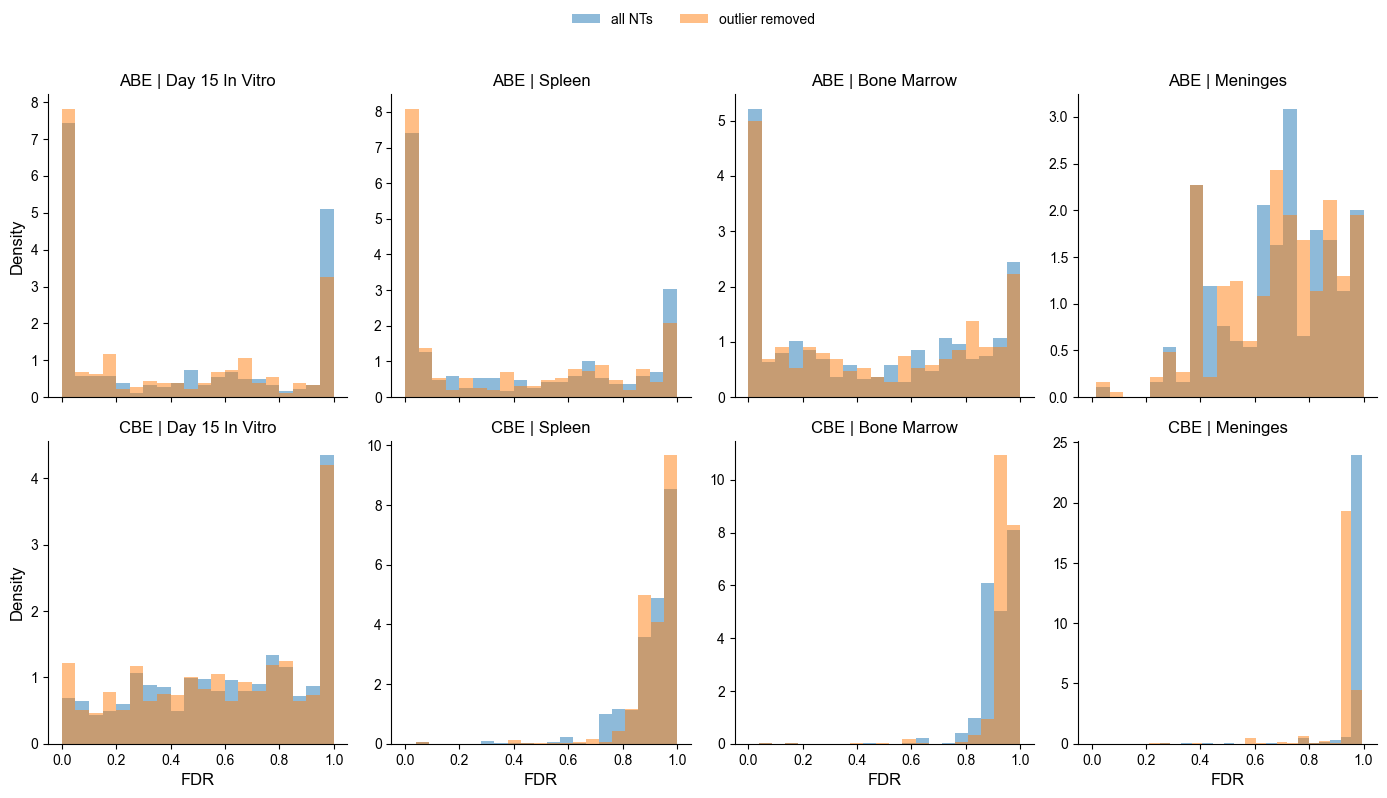

In [131]:
import numpy as np
import matplotlib.pyplot as plt

# Layout: 2 rows (ABE/CBE) x 4 cols (tissues)
fig, ax = plt.subplots(2, 4, figsize=(14, 8), sharex=True, sharey=False)

tissues = ['d15', 'spleen', 'bm', 'men']
titles = [name_dict[t] for t in tissues]  # uses your name_dict

# Helper: compute shared bins (important for fair comparison)
def shared_bins(x1, x2, bins=20):
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    x1 = x1[np.isfinite(x1)]
    x2 = x2[np.isfinite(x2)]
    lo = min(x1.min() if x1.size else 0, x2.min() if x2.size else 0)
    hi = max(x1.max() if x1.size else 1, x2.max() if x2.size else 1)
    if lo == hi:  # avoid zero-range bins
        lo -= 0.5
        hi += 0.5
    return np.linspace(lo, hi, bins + 1)

# ======= ABE row (row 0) =======
for i, t in enumerate(tissues):
    col = f'FDR_{t}_fishers'  # <-- change if your column naming differs

    x_kept = LFC_ABE[col].dropna()
    x_removed = combined_LFC_FDR_ABE_removed[col].dropna()

    bins = shared_bins(x_kept, x_removed, bins=20)

    ax[0, i].hist(x_kept, density = True,bins=bins, alpha=0.5, label='all NTs')
    ax[0, i].hist(x_removed,  density = True, bins=bins, alpha=0.5, label='outlier removed')

    ax[0, i].set_title(f'ABE | {titles[i]}', fontsize=12)
    ax[0, i].spines[['top', 'right']].set_visible(False)

# ======= CBE row (row 1) =======
for i, t in enumerate(tissues):
    col = f'FDR_{t}_fishers'  # <-- change if needed

    x_kept = LFC_CBE[col].dropna()
    x_removed = combined_LFC_FDR_CBE_removed[col].dropna()

    bins = shared_bins(x_kept, x_removed, bins=20)

    ax[1, i].hist(x_kept, bins=bins, density = True, alpha=0.5, label='all NTs')
    ax[1, i].hist(x_removed, bins=bins,  density = True,alpha=0.5, label='outlier removed')

    ax[1, i].set_title(f'CBE | {titles[i]}', fontsize=12)
    ax[1, i].spines[['top', 'right']].set_visible(False)
    ax[1, i].set_xlabel('FDR', fontsize=12)

# Shared y label on left side
ax[0, 0].set_ylabel('Density', fontsize=12)
ax[1, 0].set_ylabel('Density', fontsize=12)

# One legend for the whole figure (cleaner than 8 legends)
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('figures/bc_3_2.pdf')
plt.show()

## Analysis 4: Correlate BC screen LFC to EPO screen LFC of TARGETING GUIDES.

In [ ]:
targeting_names = ['targeting guide', 'essential truncation guide']
guides_focused_targ = LIB[LIB['classification'].isin(targeting_names)]['gRNA_id']
control_names = ['safe-targeting control',
       'non-targeting control']
guides_nontarg = LIB[LIB['classification'].isin(control_names)]['gRNA_id']

ABE_targ = ABE_EPO_LFC_table_w_editing_z_score[ABE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
CBE_targ = CBE_EPO_LFC_table_w_editing_z_score[CBE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
ABE_nontarg = ABE_EPO_LFC_table_w_editing_z_score[ABE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)
CBE_nontarg = CBE_EPO_LFC_table_w_editing_z_score[CBE_EPO_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)

ABE_targ_bc = ABE_BC_LFC_table_w_editing_z_score[ABE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
CBE_targ_bc = CBE_BC_LFC_table_w_editing_z_score[CBE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_focused_targ)].reset_index(drop=True)
ABE_nontarg_bc = ABE_BC_LFC_table_w_editing_z_score[ABE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)
CBE_nontarg_bc = CBE_BC_LFC_table_w_editing_z_score[CBE_BC_LFC_table_w_editing_z_score['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True)

2
170
1
170
170
2
170
897
5
897
5
897
5
897
5


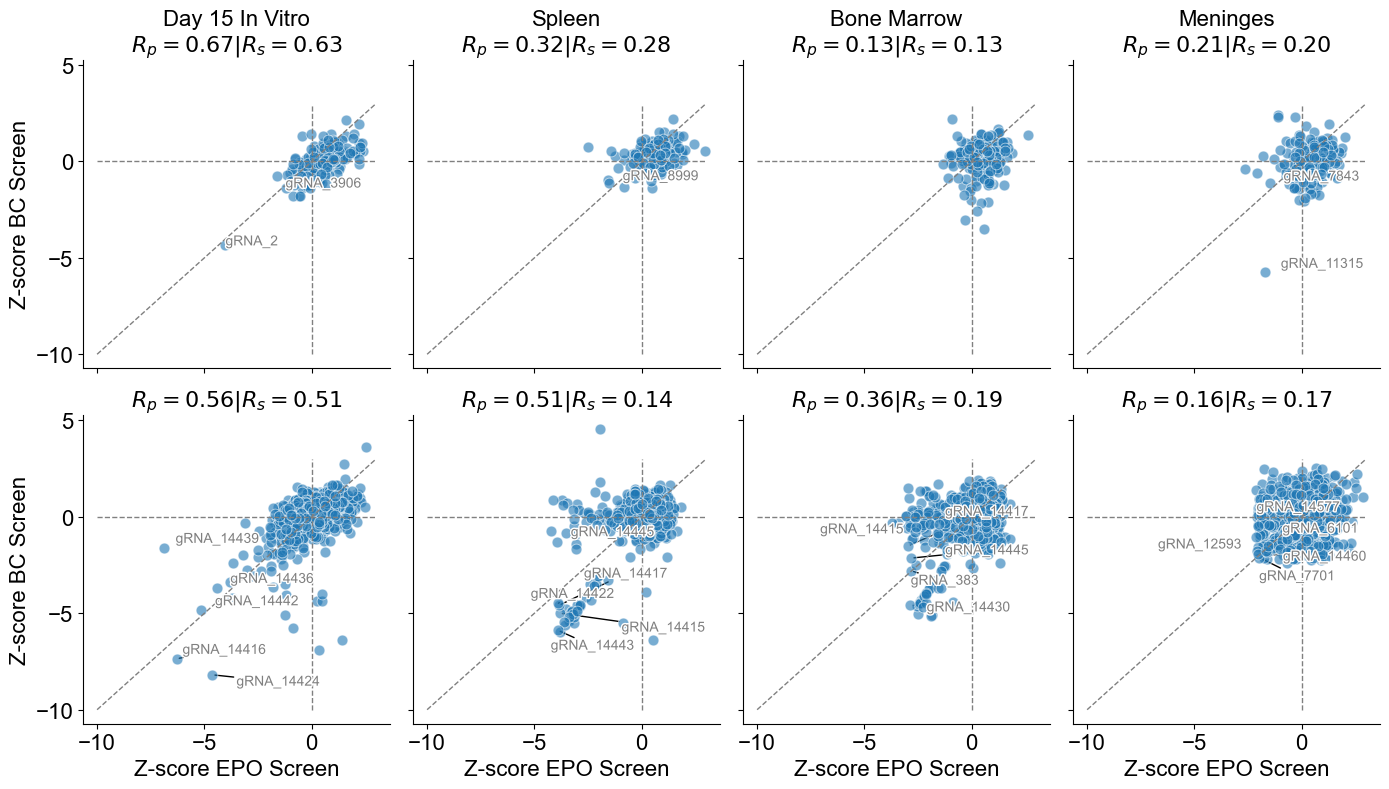

In [149]:
fig, ax = plt.subplots(2, 4, figsize = (14, 8), sharex=True, sharey = True)

conditions = ['d5', 'd15', 'spleen', 'bm', 'men']
conditions_og = ['d5','d15','spleen','bonemarrow','meninges']

name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))
name_dict_og = dict(zip(conditions_og, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))

# ABE first
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = ABE_targ[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = ABE_targ_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc, on='gRNA_id')

    # correlation calculation 
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        if i >0:
            adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    print(len(df))
    # color_dict_classification = {'non-targeting control':greens[4], 'safe-targeting control':yellows[4]}
    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[0][i], s=60, alpha=.6, legend=False)
    ax[0][i].spines[['top', 'right']].set_visible(False)
    ax[0][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[0][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].set_title(f'{name_dict[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[0][i].set_ylabel(f'Z-score BC Screen', fontsize=16)
    
# then CBE
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = CBE_targ[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = CBE_targ_bc[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc)
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    print(len(df))

    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True)[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[1][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        adjust_text(texts,only_move={'texts':'xy'}, ax=ax[1][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[1][i], s=60, alpha=.6, legend=False)
    ax[1][i].spines[['top', 'right']].set_visible(False)
    ax[1][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[1][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].set_title(f'$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[1][i].set_xlabel('Z-score EPO Screen', fontsize=16)
    ax[1][i].set_ylabel('Z-score BC Screen', fontsize=16)

fig.tight_layout()
plt.savefig('figures/bc_4.pdf')

## Analysis 5: correlation of BC method and input method of the EPO data

## Analysis 6: heatmaps of examples that you can get different LFCs from the two method.

In [59]:
#and perform comparison
FDR_cutoff = .1
input_reads_cutoff = 100
input_reads_cutoff_og = 10
above_threshold_gRNAs_focused = list(LFC_CBE[(LFC_CBE['sensor_reads']>=input_reads_cutoff)]) + list(LFC_ABE[LFC_ABE['sensor_reads']>=input_reads_cutoff]['gRNA_id'])

# for focused library
fishers_hits_CBE_focused_enrichers = []
fishers_hits_CBE_focused_depleters = []
fishers_hits_ABE_focused_enrichers = []
fishers_hits_ABE_focused_depleters = []
fishers_ABE_hits = []
fishers_CBE_hits = []

conditions_focused = ['d15', 'spleen', 'bm', 'men']
name_dict_focused = dict(zip(
    conditions_focused,
    ['In Vitro','Spleen','Bone Marrow', 'Meninges']
))

In [60]:
LFC_cutoff = 1
for tissue in conditions_focused:
    # fishers
        # focused
    ABE_fishers_enrichers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE[f'LFC_median_{tissue}']>LFC_cutoff)]
    CBE_fishers_enrichers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE[f'LFC_median_{tissue}']>LFC_cutoff)]
    ABE_fishers_depleters = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE[f'LFC_median_{tissue}']< -LFC_cutoff)]
    CBE_fishers_depleters = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE[f'LFC_median_{tissue}']< -LFC_cutoff)]

    ABE_fishers_hits = pd.concat([ABE_fishers_enrichers, ABE_fishers_depleters]).reset_index(drop=True)
    CBE_fishers_hits = pd.concat([CBE_fishers_enrichers, CBE_fishers_depleters]).reset_index(drop=True)
    # # stouffers
    #     # focused
    # ABE_stouffers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    # CBE_NGG_stouffers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    fishers_hits_ABE_focused_depleters.append(list(ABE_fishers_depleters['gRNA_id']))
    fishers_hits_ABE_focused_enrichers.append(list(ABE_fishers_enrichers['gRNA_id']))
    fishers_hits_CBE_focused_depleters.append(list(CBE_fishers_depleters['gRNA_id']))
    fishers_hits_CBE_focused_enrichers.append(list(CBE_fishers_enrichers['gRNA_id']))

    fishers_ABE_hits.append(list(ABE_fishers_hits['gRNA_id']))
    fishers_CBE_hits.append(list(CBE_fishers_hits['gRNA_id']))

In [61]:
#and perform comparison
FDR_cutoff = .1
input_reads_cutoff = 100
input_reads_cutoff_og = 10
above_threshold_gRNAs_focused_bc = list(LFC_CBE_VS_BC[(LFC_CBE_VS_BC['sensor_reads_epo']>=input_reads_cutoff) & (LFC_CBE_VS_BC['sensor_reads_bc']>=input_reads_cutoff) ]['gRNA_id']) + list(LFC_ABE_VS_BC[ (LFC_ABE_VS_BC['sensor_reads_bc']>=input_reads_cutoff) & (LFC_ABE_VS_BC['sensor_reads_epo']>=input_reads_cutoff)]['gRNA_id'])
# for focused library
fishers_hits_CBE_focused_enrichers_vs_bc = []
fishers_hits_CBE_focused_depleters_vs_bc = []
fishers_hits_ABE_focused_enrichers_vs_bc = []
fishers_hits_ABE_focused_depleters_vs_bc = []
fishers_ABE_hits_vs_bc = []
fishers_CBE_hits_vs_bc = []

conditions_focused = ['d15', 'spleen', 'bm', 'men']
name_dict_focused = dict(zip(
    conditions_focused,
    ['In Vitro','Spleen','Bone Marrow', 'Meninges']
))

In [62]:
LFC_cutoff = 1
for tissue in conditions_focused:
    # fishers
        # focused
    ABE_fishers_enrichers_bc = LFC_ABE_VS_BC[(LFC_ABE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE_VS_BC[f'LFC_median_{tissue}']>LFC_cutoff)]
    CBE_fishers_enrichers_bc = LFC_CBE_VS_BC[(LFC_CBE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE_VS_BC[f'LFC_median_{tissue}']>LFC_cutoff)]
    ABE_fishers_depleters_bc = LFC_ABE_VS_BC[(LFC_ABE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE_VS_BC[f'LFC_median_{tissue}']< -LFC_cutoff)]
    CBE_fishers_depleters_bc = LFC_CBE_VS_BC[(LFC_CBE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE_VS_BC[f'LFC_median_{tissue}']< -LFC_cutoff)]

    ABE_fishers_hits_bc = pd.concat([ABE_fishers_enrichers_bc, ABE_fishers_depleters_bc]).reset_index(drop=True)
    CBE_fishers_hits_bc = pd.concat([CBE_fishers_enrichers_bc, CBE_fishers_depleters_bc]).reset_index(drop=True)
    # # stouffers
    #     # focused
    # ABE_stouffers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    # CBE_NGG_stouffers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    fishers_hits_ABE_focused_depleters_vs_bc.append(list(ABE_fishers_depleters_bc['gRNA_id']))
    fishers_hits_ABE_focused_enrichers_vs_bc.append(list(ABE_fishers_enrichers_bc['gRNA_id']))
    fishers_hits_CBE_focused_depleters_vs_bc.append(list(CBE_fishers_depleters_bc['gRNA_id']))
    fishers_hits_CBE_focused_enrichers_vs_bc.append(list(CBE_fishers_enrichers_bc['gRNA_id']))

    fishers_ABE_hits_vs_bc.append(list(ABE_fishers_hits_bc['gRNA_id']))
    fishers_CBE_hits_vs_bc.append(list(CBE_fishers_hits_bc['gRNA_id']))

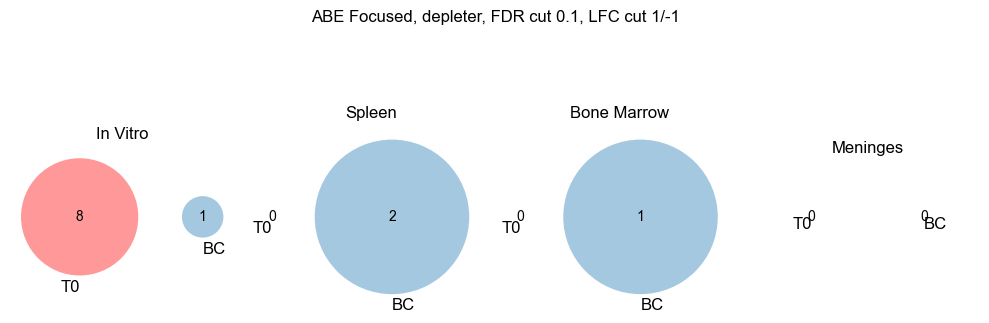

In [63]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused_depleters[idx]
    list2 = fishers_hits_ABE_focused_depleters_vs_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('ABE Focused, depleter, FDR cut 0.1, LFC cut 1/-1')
fig.tight_layout()

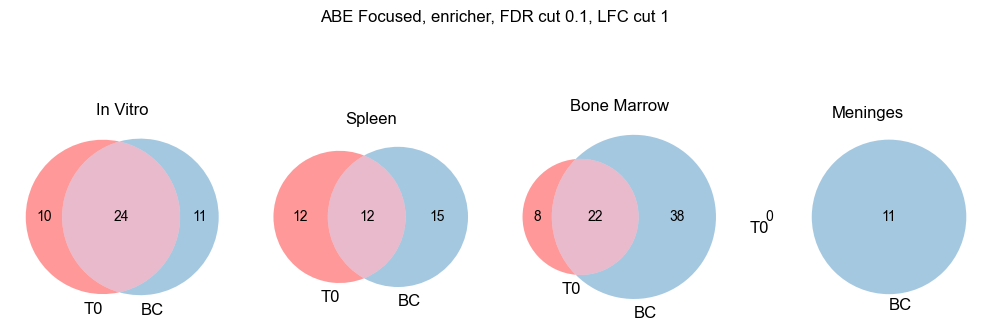

In [66]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused_enrichers[idx]
    list2 = fishers_hits_ABE_focused_enrichers_vs_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('ABE Focused, enricher, FDR cut 0.1, LFC cut 1')
fig.tight_layout()

In [71]:
LFC_ABE['classification']

0            targeting guide
1            targeting guide
2            targeting guide
3            targeting guide
4            targeting guide
               ...          
371    non-targeting control
372    non-targeting control
373    non-targeting control
374    non-targeting control
375    non-targeting control
Name: classification, Length: 376, dtype: object

In [73]:
fp = 'counts/focused/'
ABE_BC_COUNTS = pd.read_csv(fp + 'FC_ABE_BC_COUNTS.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv(fp + 'FC_ABE_EPO_COUNTS.txt', sep='\t')
# CBE_BC_COUNTS = pd.read_csv(fp + 'CBE_BC_COUNTS.txt', sep='\t')
# CBE_EPO_COUNTS = pd.read_csv(fp + 'CBE_EPO_COUNTS.txt', sep='\t')
ABE_BC_COUNTS = ABE_BC_COUNTS[ABE_BC_COUNTS.columns[2:]]
ABE_EPO_COUNTS = ABE_EPO_COUNTS[ABE_EPO_COUNTS.columns[2:]]
# CBE_EPO_COUNTS = CBE_EPO_COUNTS[CBE_EPO_COUNTS.columns[2:]]
# CBE_BC_COUNTS = CBE_BC_COUNTS[CBE_BC_COUNTS.columns[2:]]

In [74]:
ABE_BC_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,men1,men2,men3,men4,men5
0,3604.0,7590.0,9740.0,2905.0,335.0,1953.0,897.0,47.0,2676.0,6806.0,...,4626.0,677.0,5696.0,8075.0,9193.0,189.0,9928.0,599.0,2556.0,10.0
1,18935.0,11979.0,12492.0,38218.0,8043.0,20875.0,24244.0,566.0,9877.0,7621.0,...,2558.0,10021.0,14030.0,13184.0,6526.0,785.0,3639.0,2569.0,3401.0,3093.0
2,44200.0,24893.0,26740.0,159395.0,14552.0,17922.0,24984.0,1288.0,27594.0,20444.0,...,26270.0,2220.0,8740.0,12995.0,5394.0,112814.0,38552.0,81248.0,2512.0,18412.0
3,4691.0,6452.0,8321.0,28166.0,4822.0,7193.0,5613.0,63.0,2562.0,3899.0,...,1068.0,2299.0,62.0,341.0,1546.0,752.0,255.0,8469.0,6497.0,97730.0
4,15547.0,13045.0,15106.0,90114.0,4516.0,21661.0,8079.0,252.0,9388.0,13387.0,...,5088.0,24335.0,6931.0,25028.0,3867.0,481.0,40145.0,4544.0,1352.0,6775.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,51283.0,40323.0,49641.0,266685.0,36486.0,27248.0,76050.0,1107.0,36001.0,35266.0,...,82476.0,123863.0,4442.0,47190.0,4851.0,38375.0,22729.0,54721.0,25292.0,36717.0
372,29168.0,27303.0,35946.0,109799.0,13142.0,27212.0,26981.0,721.0,22663.0,26213.0,...,35798.0,97094.0,9731.0,22846.0,18715.0,11677.0,29545.0,51894.0,15496.0,21683.0
373,51625.0,50847.0,61386.0,340616.0,30955.0,18169.0,65875.0,1308.0,56724.0,41785.0,...,39083.0,4397.0,13708.0,33940.0,17456.0,27987.0,84385.0,383042.0,24419.0,61943.0
374,38285.0,37569.0,45677.0,185270.0,20286.0,56847.0,45879.0,685.0,58389.0,26677.0,...,17330.0,2143.0,2337.0,40502.0,23061.0,42583.0,12758.0,40747.0,58187.0,59043.0
